In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib_inline
import seaborn as sns

In [2]:
# get data
c = pd.read_csv("category.csv")
p = pd.read_csv("products.csv")
sl = pd.read_csv("sales.csv")
st = pd.read_csv("stores.csv")
w = pd.read_csv("warranty.csv")

In [3]:
# merge data
df1 = pd.merge(c, p, left_on='category_id', right_on='Category_ID', how='left')
df2 = pd.merge(df1, sl, left_on='Product_ID', right_on='product_id', how='left')
df3 = pd.merge(df2, st, left_on='store_id', right_on='Store_ID', how='left')
data = pd.merge(df3, w, left_on='sale_id', right_on='sale_id', how='left')

In [4]:
# drop repeated columns
data.drop(columns=["Category_ID", "Product_ID", "Store_ID"], inplace=True)

In [5]:
# add "revenue" column
data["Revenue"] = data["Price"] * data["quantity"]
# change sale_date to date_time datatype
data['sale_date'] = pd.to_datetime(data['sale_date'], dayfirst=True)
# add "YearQuarter" column
data['YearQuarter'] = data['sale_date'].dt.to_period('Q')

In [6]:
# store data
data.to_csv("Full_Data.csv", index=False)

In [7]:
data.head()

,category_id,category_name,Product_Name,Launch_Date,Price,sale_id,sale_date,store_id,product_id,quantity,Store_Name,City,Country,claim_id,claim_date,repair_status,Revenue,YearQuarter
0,CAT-1,Laptop,MacBook,17/09/2023,1149,PX-36970,2022-03-19,ST-9,P-1,4,Apple Park Visitor Center,Cupertino,United States,CL-33717,13/03/2024,In Progress,4596,2022Q1
1,CAT-1,Laptop,MacBook,17/09/2023,1149,QI-121888,2023-05-29,ST-55,P-1,5,Apple Highpoint,Melbourne,Australia,CL-71614,13/01/2024,In Progress,5745,2023Q2
2,CAT-1,Laptop,MacBook,17/09/2023,1149,GR-5145,2024-05-12,ST-27,P-1,10,Apple Rosenstrasse,Munich,Germany,CL-74967,02/01/2024,In Progress,11490,2024Q2
3,CAT-1,Laptop,MacBook,17/09/2023,1149,ZW-5345,2021-04-28,ST-12,P-1,7,Apple North Michigan Avenue,Chicago,United States,CL-40335,04/09/2024,Rejected,8043,2021Q2
4,CAT-1,Laptop,MacBook,17/09/2023,1149,MB-00191,2023-01-01,ST-75,P-1,6,Apple Beijing SKP,Beijing,China,CL-24823,07/03/2024,In Progress,6894,2023Q1


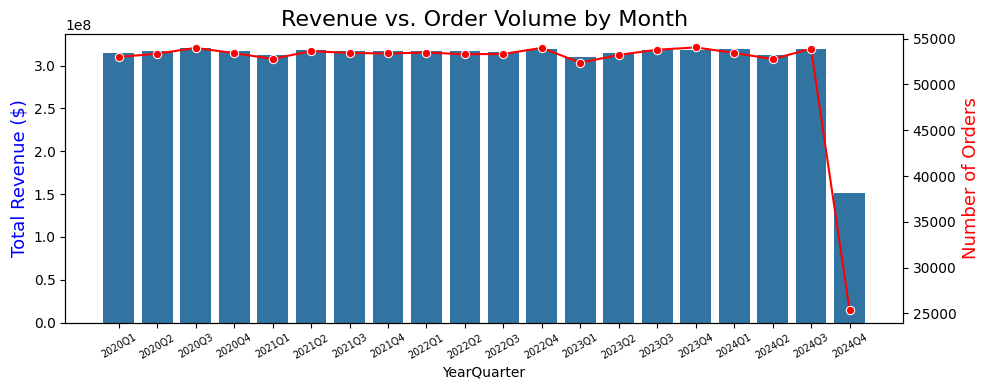

<Figure size 640x480 with 0 Axes>

In [ ]:
date_plot = data.sort_values("YearQuarter")
agg = date_plot.groupby("YearQuarter").agg(
    TotalRevenue=("Revenue", "sum"),
    OrderCount=("sale_id", "count") 
).reset_index()
agg["YearQuarter"] = agg["YearQuarter"].astype(str)


fig, ax1 = plt.subplots(figsize=(10, 4))

sns.barplot(data=agg, x="YearQuarter", y="TotalRevenue", 
                estimator=sum, errorbar=None, ax=ax1)
ax1.set_ylabel("Total Revenue ($)", size=13, color="blue")

ax2 = ax1.twinx()
sns.lineplot(data=agg, x="YearQuarter", y="OrderCount",
                estimator=len ,marker="o", color="red", ax=ax2)
ax2.set_ylabel("Number of Orders", size=13, color="red")

plt.title("Revenue vs. Order Volume by Month", size=16)
ax1.tick_params(axis='x', rotation=30, labelsize=7)

plt.tight_layout()
plt.show()

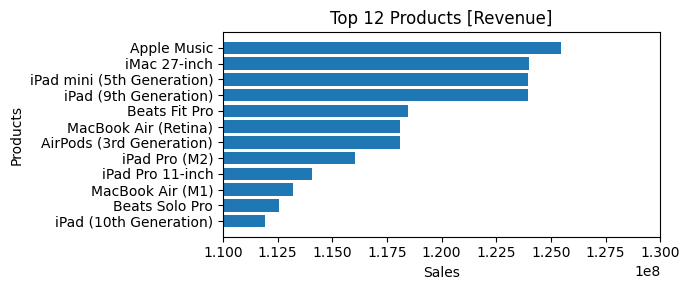

In [9]:
top12_Products_Revenue = data.groupby("Product_Name")["Revenue"].sum().sort_values().tail(12)

plt.figure(figsize=(7,3))
plt.barh(top12_Products_Revenue.index, top12_Products_Revenue.values)

plt.title("Top 12 Products [Revenue]")
plt.xlabel("Sales")
plt.ylabel('Products')

plt.xlim(110000000, 130000000)
plt.tight_layout()
plt.show()

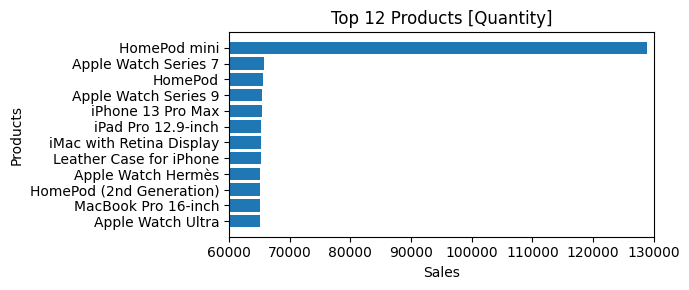

In [10]:
top12_Products_Quantity = data.groupby("Product_Name")["quantity"].sum().sort_values().tail(12)

plt.figure(figsize=(7,3))
plt.barh(top12_Products_Quantity.index, top12_Products_Quantity.values)

plt.title("Top 12 Products [Quantity]")
plt.xlabel("Sales")
plt.ylabel("Products")

plt.xlim(60000, 130000)
plt.tight_layout()
plt.show()

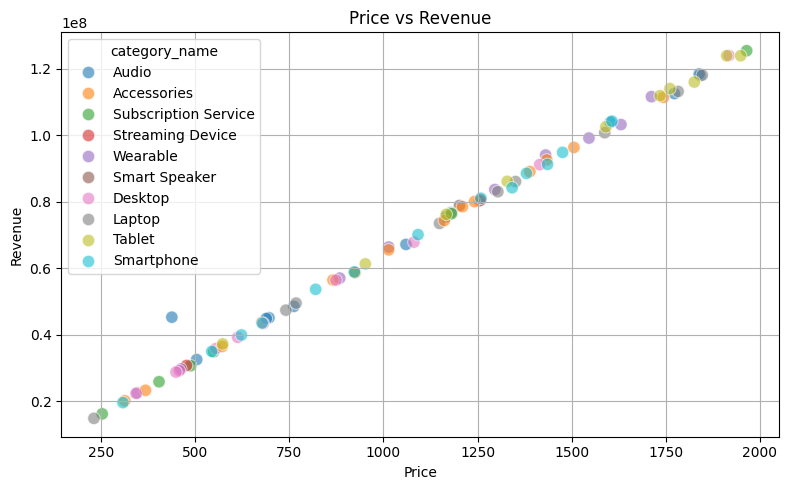

In [12]:
products_data = data.groupby("Product_Name").agg({"Price": "first", 
                                                "Revenue": "sum",
                                                "category_name": "first"}).reset_index()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=products_data, x="Price", y="Revenue", hue="category_name", alpha=0.6, s=80)
plt.title("Price vs Revenue")
plt.xlabel("Price")
plt.ylabel("Revenue")
plt.grid()
plt.tight_layout()
plt.show()

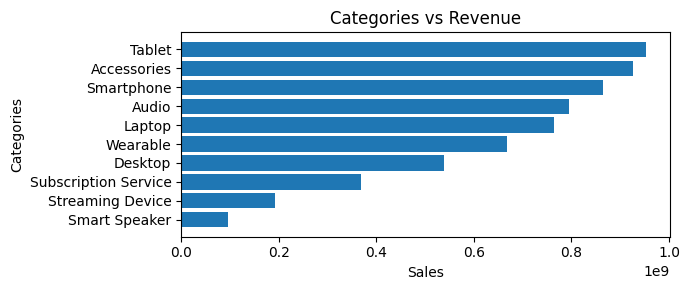

In [13]:
Categories_Revenue = data.groupby("category_name")["Revenue"].sum().sort_values()

plt.figure(figsize=(7,3))
plt.barh(Categories_Revenue.index, Categories_Revenue.values)

plt.title("Categories vs Revenue")
plt.xlabel("Sales")
plt.ylabel("Categories")

plt.tight_layout()
plt.show()

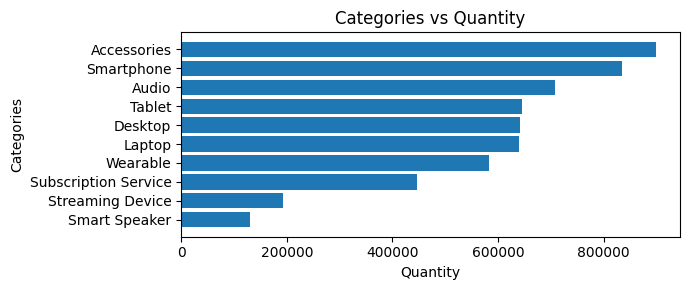

In [ ]:
Categories_Quantity = data.groupby("category_name")["quantity"].sum().sort_values().tail(12)

plt.figure(figsize=(7,3))
plt.barh(Categories_Quantity.index, Categories_Quantity.values)

plt.title("Categories vs Quantity")
plt.xlabel("Quantity")
plt.ylabel("Categories")

plt.tight_layout()
plt.show()